In [1]:
import geopandas as gpd

In [2]:
cidades = gpd.read_file("shapes/cidades.shp")
municipios_bacia = gpd.read_file("shapes/municipios_bacia.shp")
rodovias = gpd.read_file("shapes/rodovias.shp")
nordeste = gpd.read_file("shapes/nordeste.shp")

In [14]:
municipios_bacia["limites"] = municipios_bacia.boundary
municipios_bacia.head(2)

,fid,cd_mun,nm_mun,sigla_uf,area_km2,hab_km2_dd,pop2021,x,y,id,geometry,limites
0,1.0,2100154,Água Doce do Maranhão,MA,442.292,29.0,12731.0,-42.166195,-2.946424,3,"POLYGON ((-42.17657 -2.84415, -42.17639 -2.844...","LINESTRING (-42.17657 -2.84415, -42.17639 -2.8..."
1,3.0,2100501,Alto Parnaíba,MA,11127.384,1.0,11233.0,-46.213301,-9.508467,268,"POLYGON ((-45.87754 -10.06378, -45.87726 -10.0...","LINESTRING (-45.87754 -10.06378, -45.87726 -10..."


<Axes: >

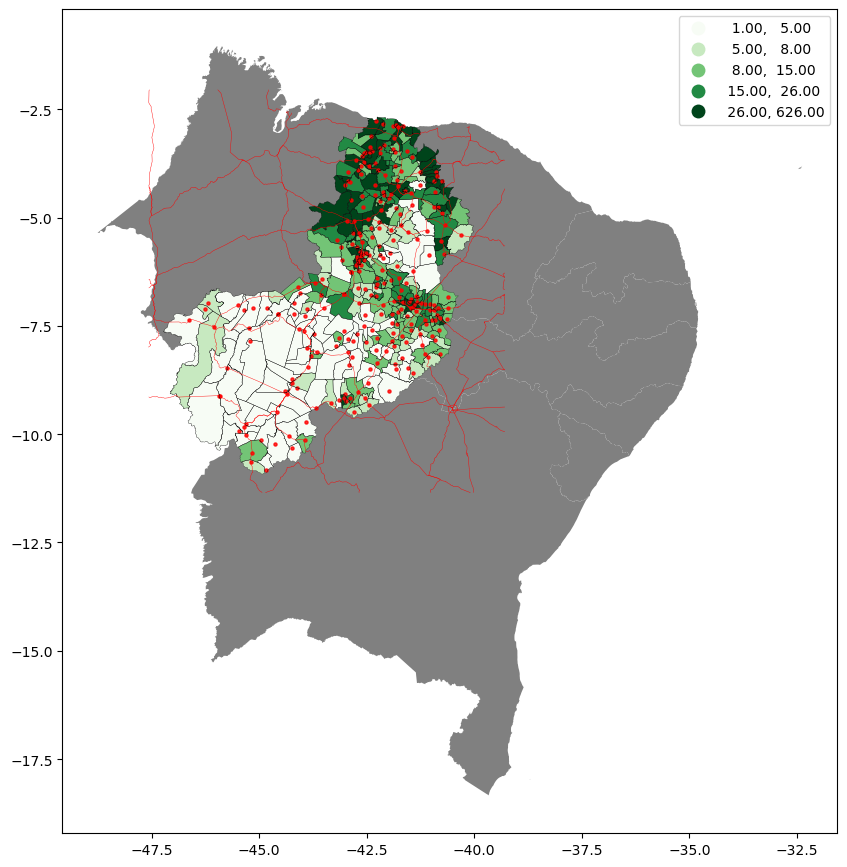

In [4]:
ax = nordeste.plot(figsize=(10, 15), color="gray")
municipios_bacia.plot(ax=ax,column="hab_km2_dd", cmap='Greens', scheme='quantiles', legend=True)
municipios_bacia["limites"].plot(ax=ax, color="black", linewidth=0.2)
cidades.plot(ax=ax, color="red", alpha=0.8, markersize=5)
rodovias.plot(ax=ax, color="red", linewidth=0.3)

In [29]:
bacia_uf = municipios_bacia[["sigla_uf", "geometry", "pop2021"]]
bacia_uf.sample(5)

,sigla_uf,geometry,pop2021
192,PI,"POLYGON ((-42.28558 -8.19206, -42.32469 -8.174...",2551.0
198,PI,"POLYGON ((-41.60824 -4.30170, -41.60835 -4.301...",63829.0
43,PI,"POLYGON ((-42.83012 -6.34282, -42.82934 -6.340...",17609.0
12,MA,"POLYGON ((-43.54816 -6.15497, -43.54790 -6.154...",11280.0
271,CE,"POLYGON ((-40.87561 -4.74584, -40.87676 -4.747...",12358.0


<Axes: >

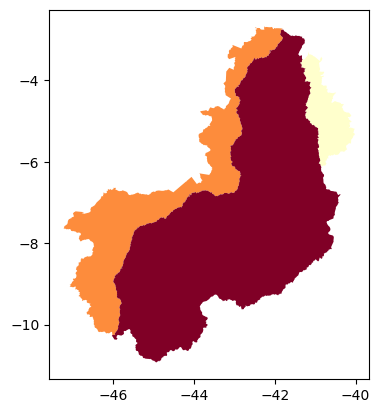

In [32]:
pop21 = bacia_uf.dissolve(by="sigla_uf", aggfunc='sum')
pop21.plot(column="pop2021", scheme='quantiles', cmap='YlOrRd')